
Iteration 16 results | k=4
Log Likelihood: -992367.022
Silhouette : 0.128

Cluster Profile (means, original scale) -- Iteration 16 (GaussianMixture + StandardScaler, spherical):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
24640,20.50901435890145,1.103,22.192999294422208,19.222099991963567,0.534,0.2270438478423778,0.4714598977985571
32094,38.179966949546454,1.177,24.412698128524323,34.12679971012715,0.261,0.4105733628219077,0.5123327705393373
15104,115.28415692943798,2.339,21.846140916731894,66.43597264107808,0.305,0.30296690095232565,0.6187296619062888
36162,29.62263197549814,1.133,17.31783430972076,27.14553176602159,0.249,0.20910992277671273,0.5897377767624958


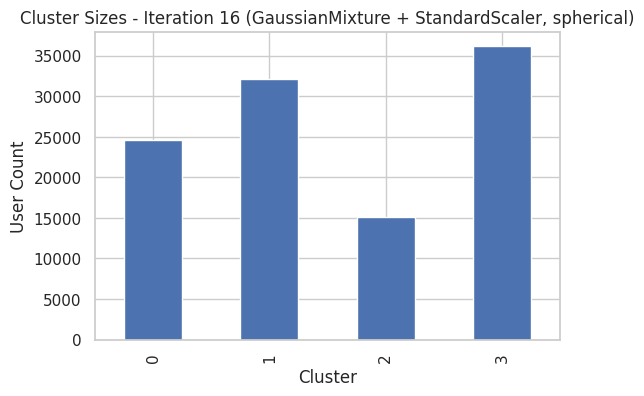

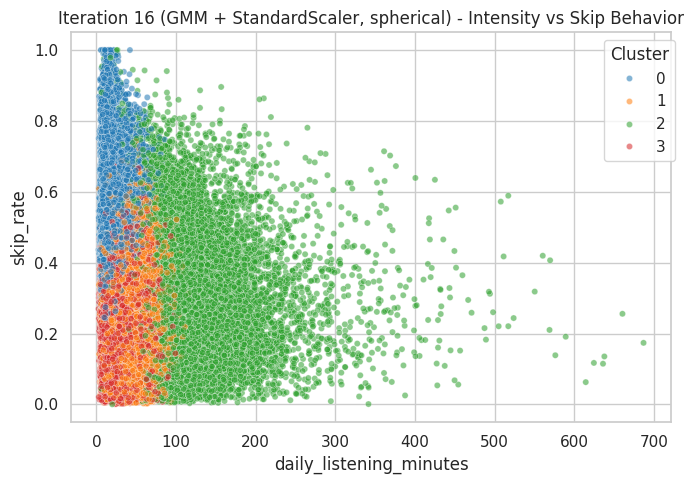

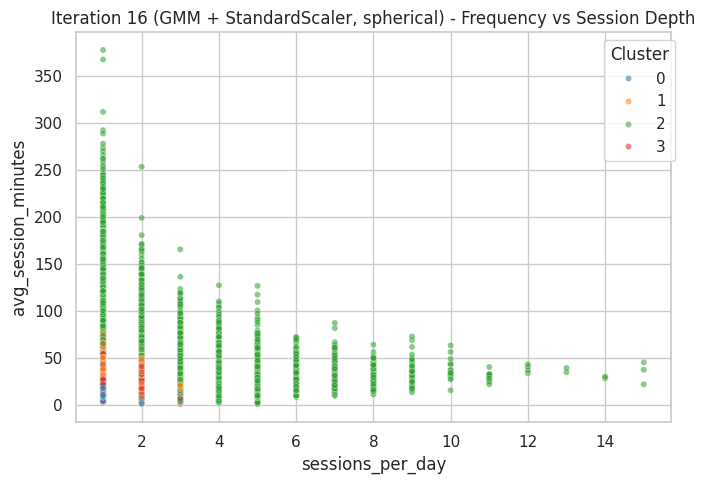

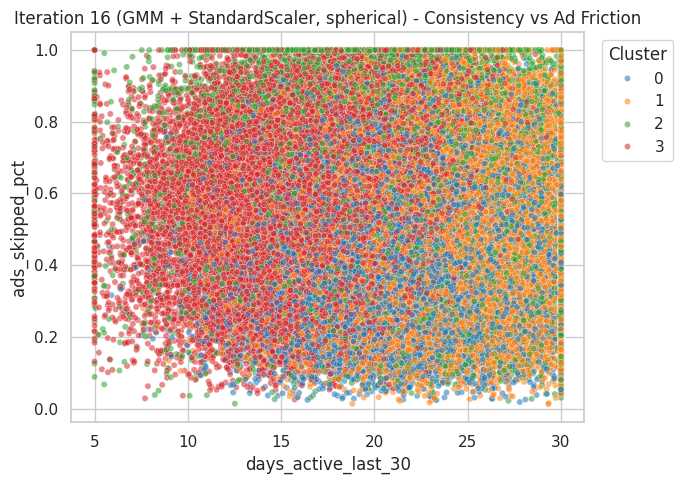

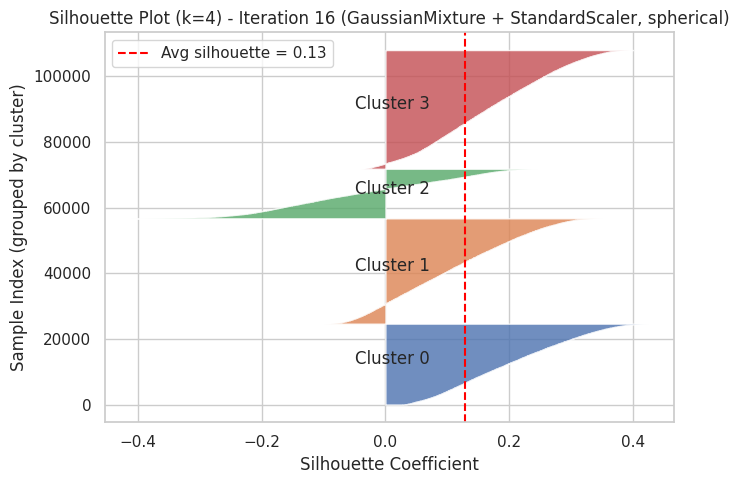

Iteration 16 Avg Silhouette: 0.128


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# -----------------------------
# Load data
# -----------------------------
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# -----------------------------
# Feature selection
# -----------------------------
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes",   # usage intensity
    "sessions_per_day",          # frequency
    "days_active_last_30",       # consistency
    "avg_session_minutes",       # depth
    "skip_rate",                 # content friction
    "liked_songs_pct",           # positive engagement
    "ads_skipped_pct"            # monetization friction
]

base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()

# -----------------------------
# Parameters
# -----------------------------
K = 4

# -----------------------------
# Standard Scaling
# -----------------------------
X16 = base[CLUSTER_FEATURES_V1].copy()

scaler = StandardScaler()
X16_scaled = scaler.fit_transform(X16)

X16 = pd.DataFrame(
    X16_scaled,
    columns=CLUSTER_FEATURES_V1,
    index=base.index
)

# -----------------------------
# Gaussian Mixture Model
# -----------------------------
gmm16 = GaussianMixture(
    n_components=K,
    covariance_type="spherical",
    random_state=42,
    n_init=5,
    max_iter=200
)

labels16 = gmm16.fit_predict(X16)

log_likelihood16 = gmm16.score(X16) * len(X16)
sill_avg_16 = silhouette_score(X16, labels16)

# -----------------------------
# Attach clusters
# -----------------------------
base_iter16 = base.copy()
base_iter16["cluster"] = labels16

print(f"\nIteration 16 results | k={K}")
print("Log Likelihood:", round(log_likelihood16, 3))
print("Silhouette :", round(sill_avg_16, 3))

# -----------------------------
# Cluster profiles
# -----------------------------
sizes16 = base_iter16["cluster"].value_counts().sort_index()

means16 = (
    base_iter16
    .groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

profile16 = means16.copy()
profile16.insert(0, "cluster_size", sizes16)

print("\nCluster Profile (means, original scale) -- Iteration 16 (GaussianMixture + StandardScaler, spherical):")
display(profile16)

# -----------------------------
# Cluster size plot
# -----------------------------
plt.figure(figsize=(6,4))
base_iter16["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 16 (GaussianMixture + StandardScaler, spherical)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

# -----------------------------
# Scatter plots
# -----------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter16,
    x="daily_listening_minutes",
    y="skip_rate",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 16 (GMM + StandardScaler, spherical) - Intensity vs Skip Behavior")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter16,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 16 (GMM + StandardScaler, spherical) - Frequency vs Session Depth")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=base_iter16,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55
)
plt.title("Iteration 16 (GMM + StandardScaler, spherical) - Consistency vs Ad Friction")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

# -----------------------------
# Silhouette Plot (MANUAL – no loop)
# -----------------------------
sil_value_16 = silhouette_samples(X16, labels16)

plt.figure(figsize=(7,5))
y_lower = 0

# Cluster 0
vals0 = sil_value_16[labels16 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals0, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size0, "Cluster 0")
y_lower = y_upper

# Cluster 1
vals1 = sil_value_16[labels16 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals1, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size1, "Cluster 1")
y_lower = y_upper

# Cluster 2
vals2 = sil_value_16[labels16 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size2, "Cluster 2")
y_lower = y_upper

# Cluster 3
vals3 = sil_value_16[labels16 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha=0.8)
plt.text(-0.05, y_lower + 0.5 * size3, "Cluster 3")
y_lower = y_upper

plt.axvline(
    x=sill_avg_16,
    color="red",
    linestyle="--",
    label=f"Avg silhouette = {sill_avg_16:.2f}"
)

plt.title("Silhouette Plot (k=4) - Iteration 16 (GaussianMixture + StandardScaler, spherical)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index (grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 16 Avg Silhouette:", round(sill_avg_16, 3))
